In [2]:
import pandas as pd


df = pd.read_csv("dataset/IMDB Dataset.csv")

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [3]:
df.shape

(50000, 2)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [5]:
df.columns

Index(['review', 'sentiment'], dtype='object')

In [6]:
df["sentiment"].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

NameError: name 'plt' is not defined

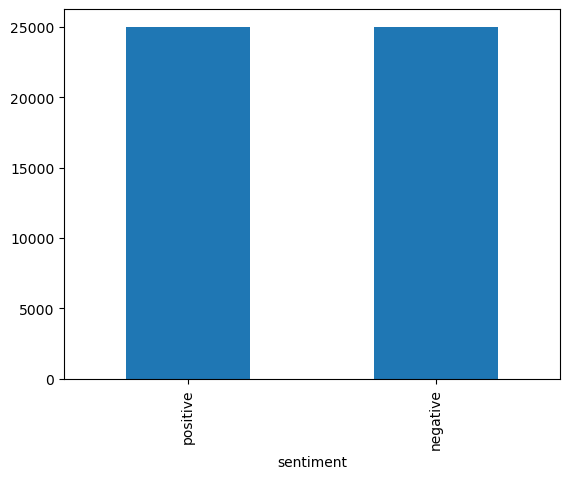

In [7]:
df["sentiment"].value_counts().plot(kind="bar")

plt.title("Distribution of Sentiments")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

In [ ]:
df.duplicated().sum()

In [ ]:
df["review"].duplicated().sum()

In [ ]:
df["review_length"] = df["review"].apply(len)

df["review_length"].describe()

In [ ]:
print("Shortest Review:")
print(df.loc[df["review_length"].idxmin(), "review"])

print("\nLongest Review:")
print(df.loc[df["review_length"].idxmax(), "review"])

In [8]:
import re

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [9]:
import nltk

nltk.download("stopwords")
nltk.download("wordnet")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Shivam\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Shivam\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [10]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

In [11]:
word = "movies"

print(lemmatizer.lemmatize(word))

movie


In [12]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r"<.*?>", " ", text)


    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    text = re.sub(r"\s+", " ", text).strip()

    words = text.split()

    words = [
         lemmatizer.lemmatize(word)

         for word in words
         if word not in stop_words

    ]
    return " ".join(words)

In [13]:
print("Original Review:")
print(df["review"].iloc[0])


#we can see here that diffrence between original and cleaned
print("\nCleaned Review:")
print(clean_text(df["review"].iloc[0]))

Original Review:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show 

In [14]:
df["cleaned_review"] = df["review"].apply(clean_text)

updated data

In [22]:
df[["review", "cleaned_review", "sentiment"]].head()

,review,cleaned_review,sentiment
0,One of the other reviewers has mentioned that ...,one reviewer mentioned watching oz episode hoo...,positive
1,A wonderful little production. <br /><br />The...,wonderful little production filming technique ...,positive
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...,positive
3,Basically there's a family where a little boy ...,basically family little boy jake think zombie ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei love time money visually stunnin...,positive


In [23]:
(df["cleaned_review"].str.strip() == "").sum()

np.int64(0)

In [24]:
df.shape

(50000, 4)

In [25]:
df.columns

Index(['review', 'sentiment', 'cleaned_review', 'label'], dtype='object')

In [26]:
df["label"] = df["sentiment"].map({
    "positive": 1,
    "negative": 0
})

In [21]:
df[["sentiment", "label"]].head()


,sentiment,label
0,positive,1
1,positive,1
2,positive,1
3,negative,0
4,positive,1


In [27]:
X = df["cleaned_review"]
y = df["label"]

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [29]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 40000
Testing samples: 10000


In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [31]:
tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

In [32]:
X_train_tfidf = tfidf.fit_transform(X_train)

In [33]:
X_test_tfidf = tfidf.transform(X_test)

In [34]:
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (40000, 50000)
Testing TF-IDF shape: (10000, 50000)


In [35]:
print(tfidf.get_feature_names_out()[:20])

['aag' 'aaliyah' 'aamir' 'aamir khan' 'aardman' 'aaron' 'aaron carter'
 'aaron eckhart' 'ab' 'aback' 'abandon' 'abandoned' 'abandoning'
 'abandonment' 'abba' 'abbey' 'abbot' 'abbott' 'abbott costello' 'abby']


In [36]:
print(X_train.iloc[0])

caught little gem totally accident back revival theatre see two old silly sci fi movie theatre packed full warning showed bunch sci fi short spoof get u mood somewhat amusing came within second audience hysteric biggest laugh came showed princess laia huge cinnamon bun instead hair head look camera give grim smile nod made even funnier gotta see chewabacca played look like muppet extremely silly stupid stop laughing dialogue drowned laughter also know star war pretty well even funnier deliberately poke fun dialogue really work audience definite


In [37]:
print(X_train_tfidf[0])

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 93 stored elements and shape (1, 50000)>
  Coords	Values
  (0, 6001)	0.07977741452698596
  (0, 25071)	0.04354871783870598
  (0, 17211)	0.08372292956682725
  (0, 45135)	0.06591740970623948
  (0, 153)	0.0878973947951516
  (0, 2879)	0.04687807040606908
  (0, 36456)	0.12482728144848444
  (0, 43677)	0.17540890249300065
  (0, 38195)	0.06843223105898581
  (0, 45899)	0.04297947257536388
  (0, 30956)	0.04906897195935362
  (0, 39780)	0.1448304776428542
  (0, 37898)	0.15975238976033226
  (0, 14579)	0.15935845348195374
  (0, 28356)	0.023428072108455166
  (0, 31996)	0.09860823481148402
  (0, 16773)	0.06175614223289846
  (0, 47552)	0.08852383427592499
  (0, 39639)	0.1666045323062243
  (0, 5273)	0.07423354725675281
  (0, 39363)	0.06106990638482569
  (0, 41142)	0.09689616095797672
  (0, 17334)	0.03468295335557066
  (0, 28199)	0.08221540041536464
  (0, 40680)	0.07146363504399426
  :	:
  (0, 35421)	0.035914551749504885
  (0, 48990)	0.04538825

In [38]:
from sklearn.linear_model import LogisticRegression

In [39]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [40]:
lr_model.fit(X_train_tfidf, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [41]:
y_pred_lr = lr_model.predict(X_test_tfidf)

In [42]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [43]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)

precision_lr = precision_score(y_test, y_pred_lr)

recall_lr = recall_score(y_test, y_pred_lr)


f1_lr = f1_score(y_test, y_pred_lr)

print("Logistic Regression Results")

print("---------------------------")

print("Accuracy :", accuracy_lr)

print("Precision:", precision_lr)

print("Recall   :", recall_lr)

print("F1-score :", f1_lr)


Logistic Regression Results
---------------------------
Accuracy : 0.9016
Precision: 0.8926476339460305
Recall   : 0.913
F1-score : 0.9027091160767253


In [44]:
print(classification_report(
    y_test,
    y_pred_lr,
    target_names=["Negative", "Positive"]
))

              precision    recall  f1-score   support

    Negative       0.91      0.89      0.90      5000
    Positive       0.89      0.91      0.90      5000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



In [45]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

print(cm_lr)

[[4451  549]
 [ 435 4565]]


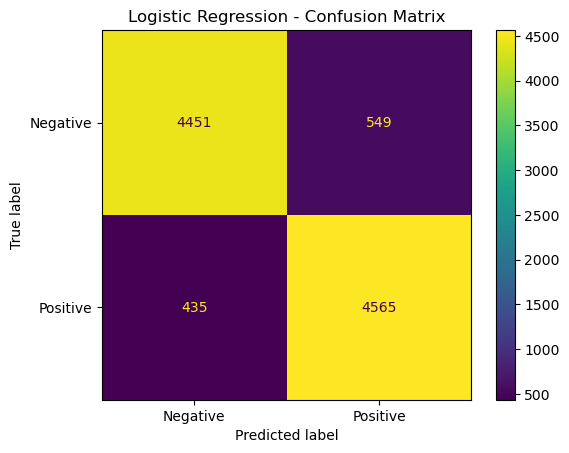

In [46]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=["Negative", "Positive"]
).plot()

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [47]:
from sklearn.svm import LinearSVC

In [48]:
svm_model = LinearSVC(
    random_state=42
)

In [49]:
svm_model.fit(X_train_tfidf, y_train)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,42


In [50]:
y_pred_svm = svm_model.predict(X_test_tfidf)

In [51]:
accuracy_svm = accuracy_score(y_test, y_pred_svm)

precision_svm = precision_score(y_test, y_pred_svm)

recall_svm = recall_score(y_test, y_pred_svm)

f1_svm = f1_score(y_test, y_pred_svm)

print("SVM Results")

print("-----------")

print("Accuracy :", accuracy_svm)

print("Precision:", precision_svm)

print("Recall   :", recall_svm)

print("F1-score :", f1_svm)


SVM Results
-----------
Accuracy : 0.9056
Precision: 0.9003158310303987
Recall   : 0.9122
F1-score : 0.9062189548976753


In [52]:
print(classification_report(
    y_test,
    y_pred_svm,
    target_names=["Negative", "Positive"]
))

              precision    recall  f1-score   support

    Negative       0.91      0.90      0.90      5000
    Positive       0.90      0.91      0.91      5000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



In [53]:
cm_svm = confusion_matrix(y_test, y_pred_lr)

print(cm_svm)

[[4451  549]
 [ 435 4565]]


In [54]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "SVM"
    ],
    "Accuracy": [
        accuracy_lr,
        accuracy_svm
    ],
    "Precision": [
        precision_lr,
        precision_svm
    ],
    "Recall": [
        recall_lr,
        recall_svm
    ],
    "F1-Score": [
        f1_lr,
        f1_svm
    ]
})

results

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.9016,0.892648,0.9130,0.902709
1,SVM,0.9056,0.900316,0.9122,0.906219


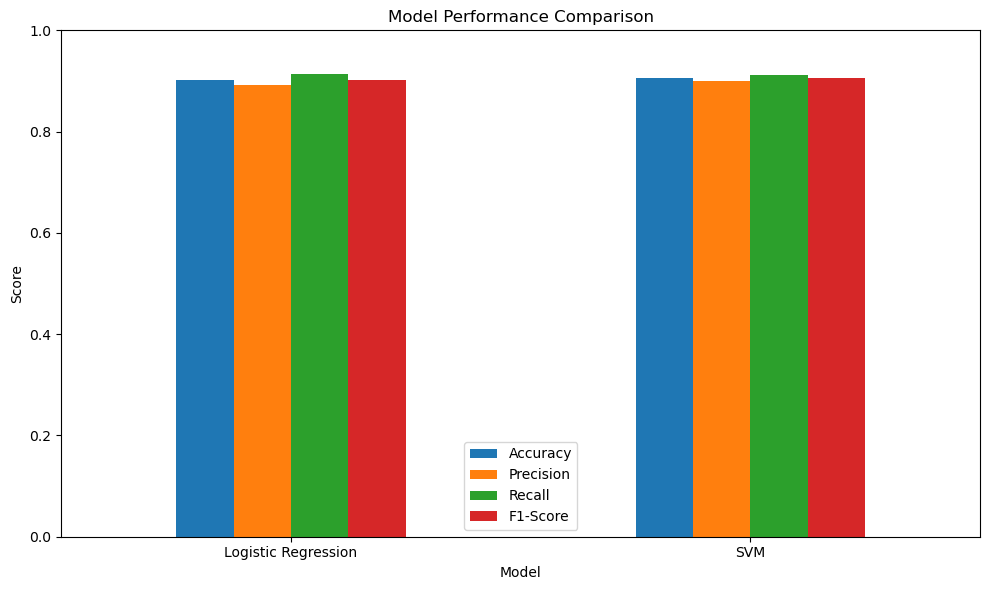

In [55]:
results.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-Score"]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

In [56]:
import joblib

In [57]:
joblib.dump(svm_model, "models/svm_sentiment_model.pkl")

['models/svm_sentiment_model.pkl']

In [58]:
joblib.dump(tfidf, "models/tfidf_vectorizer.pkl")

['models/tfidf_vectorizer.pkl']

In [59]:
loaded_model = joblib.load("models/svm_sentiment_model.pkl")
loaded_tfidf = joblib.load("models/tfidf_vectorizer.pkl")

In [60]:
new_review = "This movie was absolutely fantastic. The acting was excellent and I really enjoyed it."

In [61]:
cleaned_review = clean_text(new_review)

In [62]:
review_tfidf = loaded_tfidf.transform([cleaned_review])

In [63]:
prediction = loaded_model.predict(review_tfidf)

In [64]:
if prediction[0] == 1:
    print("Sentiment: Positive")
else:
    print("Sentiment: Negative")

Sentiment: Positive


In [65]:
new_review = "This movie was terrible. The story was boring and the acting was very poor."

cleaned_review = clean_text(new_review)

review_tfidf = loaded_tfidf.transform([cleaned_review])

prediction = loaded_model.predict(review_tfidf)

if prediction[0] == 1:
    print("Sentiment: Positive")
else:
    print("Sentiment: Negative")

Sentiment: Negative
